Device: cuda | pin_memory: True
Train normal only size: 1407
Test laying + walking size: 1033
Test normal LAYING count: 537
Test anomaly WALKING count: 496
Epoch [005/80] Loss: 0.253844
Epoch [010/80] Loss: 0.160694
Epoch [015/80] Loss: 0.080318
Epoch [020/80] Loss: 0.058176
Epoch [025/80] Loss: 0.052374
Epoch [030/80] Loss: 0.049208
Epoch [035/80] Loss: 0.044493
Epoch [040/80] Loss: 0.042407
Epoch [045/80] Loss: 0.039964
Epoch [050/80] Loss: 0.035070
Epoch [055/80] Loss: 0.033184
Epoch [060/80] Loss: 0.031679
Epoch [065/80] Loss: 0.037407
Epoch [070/80] Loss: 0.031550
Epoch [075/80] Loss: 0.034911
Epoch [080/80] Loss: 0.034693
Laying RE mean : 0.03835336
Walking RE mean: 8.119344
Threshold: 0.14894377
[[508  29]
 [  0 496]]
                  precision    recall  f1-score   support

  LAYING(normal)       1.00      0.95      0.97       537
WALKING(anomaly)       0.94      1.00      0.97       496

        accuracy                           0.97      1033
       macro avg       0.97    

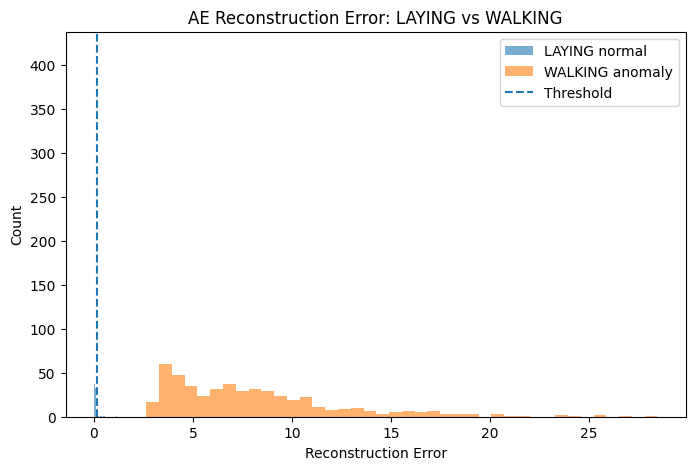

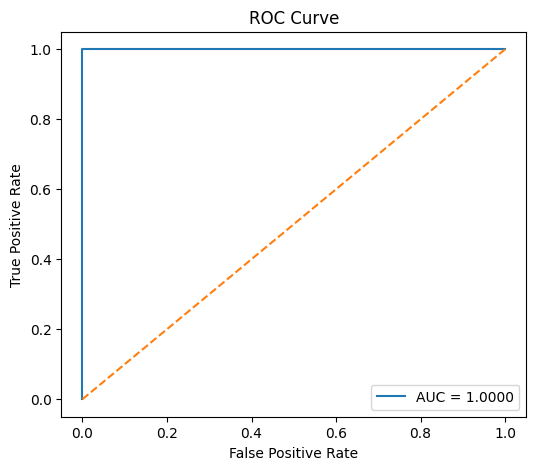

In [1]:
# 1. AutoEncoder를 사용해서 모델에 정상 Laying만 훈련
# 2. 훈련된 모델에 Laying + Walking을 넣으면
# 3. Laying의 Reconstruction Error < Walking의 Reconstruction Error

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

data_dir = "/content/drive/MyDrive/Colab Notebooks/datasets/UCI-HAR"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_GPU = DEVICE.type == "cuda"
print(f"Device: {DEVICE} | pin_memory: {USE_GPU}")

SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z"
]

WALKING = 0
LAYING = 5


def load_uci_har_laying_walking_ae(data_dir):
    data = {}

    for split in ["train", "test"]:
        inertial_dir = os.path.join(data_dir, split, "Inertial Signals")

        signals = [
            np.loadtxt(
                os.path.join(inertial_dir, f"{sig}_{split}.txt"),
                dtype=np.float32
            )
            for sig in SIGNALS
        ]

        X = np.stack(signals, axis=-1)
        y = np.loadtxt(
            os.path.join(data_dir, split, f"y_{split}.txt"),
            dtype=np.int64
        ) - 1

        data[split] = {"X": X, "y": y}

    X_train_raw, y_train = data["train"]["X"], data["train"]["y"]
    X_test_raw, y_test = data["test"]["X"], data["test"]["y"]

    train_normal_mask = y_train == LAYING
    X_train_normal_raw = X_train_raw[train_normal_mask]

    test_mask = (y_test == LAYING) | (y_test == WALKING)
    X_test_2class_raw = X_test_raw[test_mask]
    y_test_2class = y_test[test_mask]

    y_test_binary = (y_test_2class == WALKING).astype(np.int64)

    _, T, C = X_train_normal_raw.shape

    scaler = StandardScaler()
    scaler.fit(X_train_normal_raw.reshape(-1, C))

    X_train_normal = scaler.transform(
        X_train_normal_raw.reshape(-1, C)
    ).reshape(-1, T, C)

    X_test_2class = scaler.transform(
        X_test_2class_raw.reshape(-1, C)
    ).reshape(-1, T, C)

    X_train_normal = X_train_normal.transpose(0, 2, 1)
    X_test_2class = X_test_2class.transpose(0, 2, 1)

    train_dataset = TensorDataset(
        torch.tensor(X_train_normal, dtype=torch.float32)
    )

    test_dataset = TensorDataset(
        torch.tensor(X_test_2class, dtype=torch.float32),
        torch.tensor(y_test_binary, dtype=torch.long)
    )

    print(f"Train normal only size: {len(train_dataset)}")
    print(f"Test laying + walking size: {len(test_dataset)}")
    print(f"Test normal LAYING count: {(y_test_binary == 0).sum()}")
    print(f"Test anomaly WALKING count: {(y_test_binary == 1).sum()}")

    return train_dataset, test_dataset, scaler


class ConvAE(nn.Module):
    def __init__(self, in_channels=9):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose1d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose1d(32, in_channels, kernel_size=2, stride=2),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat


def compute_reconstruction_errors(model, loader, device):
    model.eval()
    errors = []

    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            x_hat = model(x)
            re = torch.mean((x - x_hat) ** 2, dim=(1, 2))
            errors.extend(re.cpu().numpy())

    return np.array(errors)

train_dataset, test_dataset, scaler = load_uci_har_laying_walking_ae(data_dir)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    pin_memory=USE_GPU
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    pin_memory=USE_GPU
)

model = ConvAE(in_channels=9).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 80

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for batch in train_loader:
        x = batch[0].to(DEVICE)

        x_hat = model(x)
        loss = criterion(x_hat, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    avg_loss = total_loss / len(train_loader.dataset)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch + 1:03d}/{epochs}] Loss: {avg_loss:.6f}")

train_re = compute_reconstruction_errors(model, train_loader, DEVICE)
test_re = compute_reconstruction_errors(model, test_loader, DEVICE)

y_test_binary = torch.cat([batch[1] for batch in test_loader]).numpy()

laying_re = test_re[y_test_binary == 0]
walking_re = test_re[y_test_binary == 1]

print("Laying RE mean :", laying_re.mean())
print("Walking RE mean:", walking_re.mean())

threshold = np.percentile(train_re, 95)
print("Threshold:", threshold)

y_pred = (test_re >= threshold).astype(int)

print(confusion_matrix(y_test_binary, y_pred))
print(classification_report(
    y_test_binary,
    y_pred,
    target_names=["LAYING(normal)", "WALKING(anomaly)"]
))

auc = roc_auc_score(y_test_binary, test_re)
print("ROC-AUC:", auc)

plt.figure(figsize=(8, 5))
plt.hist(laying_re, bins=40, alpha=0.6, label="LAYING normal")
plt.hist(walking_re, bins=40, alpha=0.6, label="WALKING anomaly")
plt.axvline(threshold, linestyle="--", label="Threshold")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("AE Reconstruction Error: LAYING vs WALKING")
plt.legend()
plt.show()

fpr, tpr, _ = roc_curve(y_test_binary, test_re)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()